<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/bagging_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
# 1. Problem Statement
#        ↓
# 2. Dataset
#        ↓
# 3. EDA
#        ↓
# 4. Data Cleaning
#        ↓
# 5. Train/Test Split
#        ↓
# 6. Decision Tree Baseline
#        ↓
# 7. Bagging Classifier
#        ↓
# 8. Experiment: n_estimators
#        ↓
# 9. Random Forest
#        ↓
# 10. Extra Trees
#        ↓
# 11. Cross Validation
#        ↓
# 12. Comparison
#        ↓
# 13. Conclusion

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [114]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [115]:
for i in df.columns:
  print(i,'->',df[i].std() )

mean radius -> 3.524048826212078
mean texture -> 4.301035768166949
mean perimeter -> 24.2989810387549
mean area -> 351.9141291816527
mean smoothness -> 0.014064128137673616
mean compactness -> 0.0528127579325122
mean concavity -> 0.0797198087078935
mean concave points -> 0.03880284485915359
mean symmetry -> 0.027414281336035712
mean fractal dimension -> 0.007060362795084459
radius error -> 0.2773127329861041
texture error -> 0.5516483926172023
perimeter error -> 2.021854554042107
area error -> 45.49100551613178
smoothness error -> 0.003002517943839067
compactness error -> 0.017908179325677377
concavity error -> 0.030186060322988394
concave points error -> 0.006170285174046866
symmetry error -> 0.008266371528798399
fractal dimension error -> 0.0026460709670891942
worst radius -> 4.833241580469324
worst texture -> 6.146257623038323
worst perimeter -> 33.60254226903635
worst area -> 569.3569926699492
worst smoothness -> 0.022832429404835458
worst compactness -> 0.15733648891374194
worst c

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [117]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

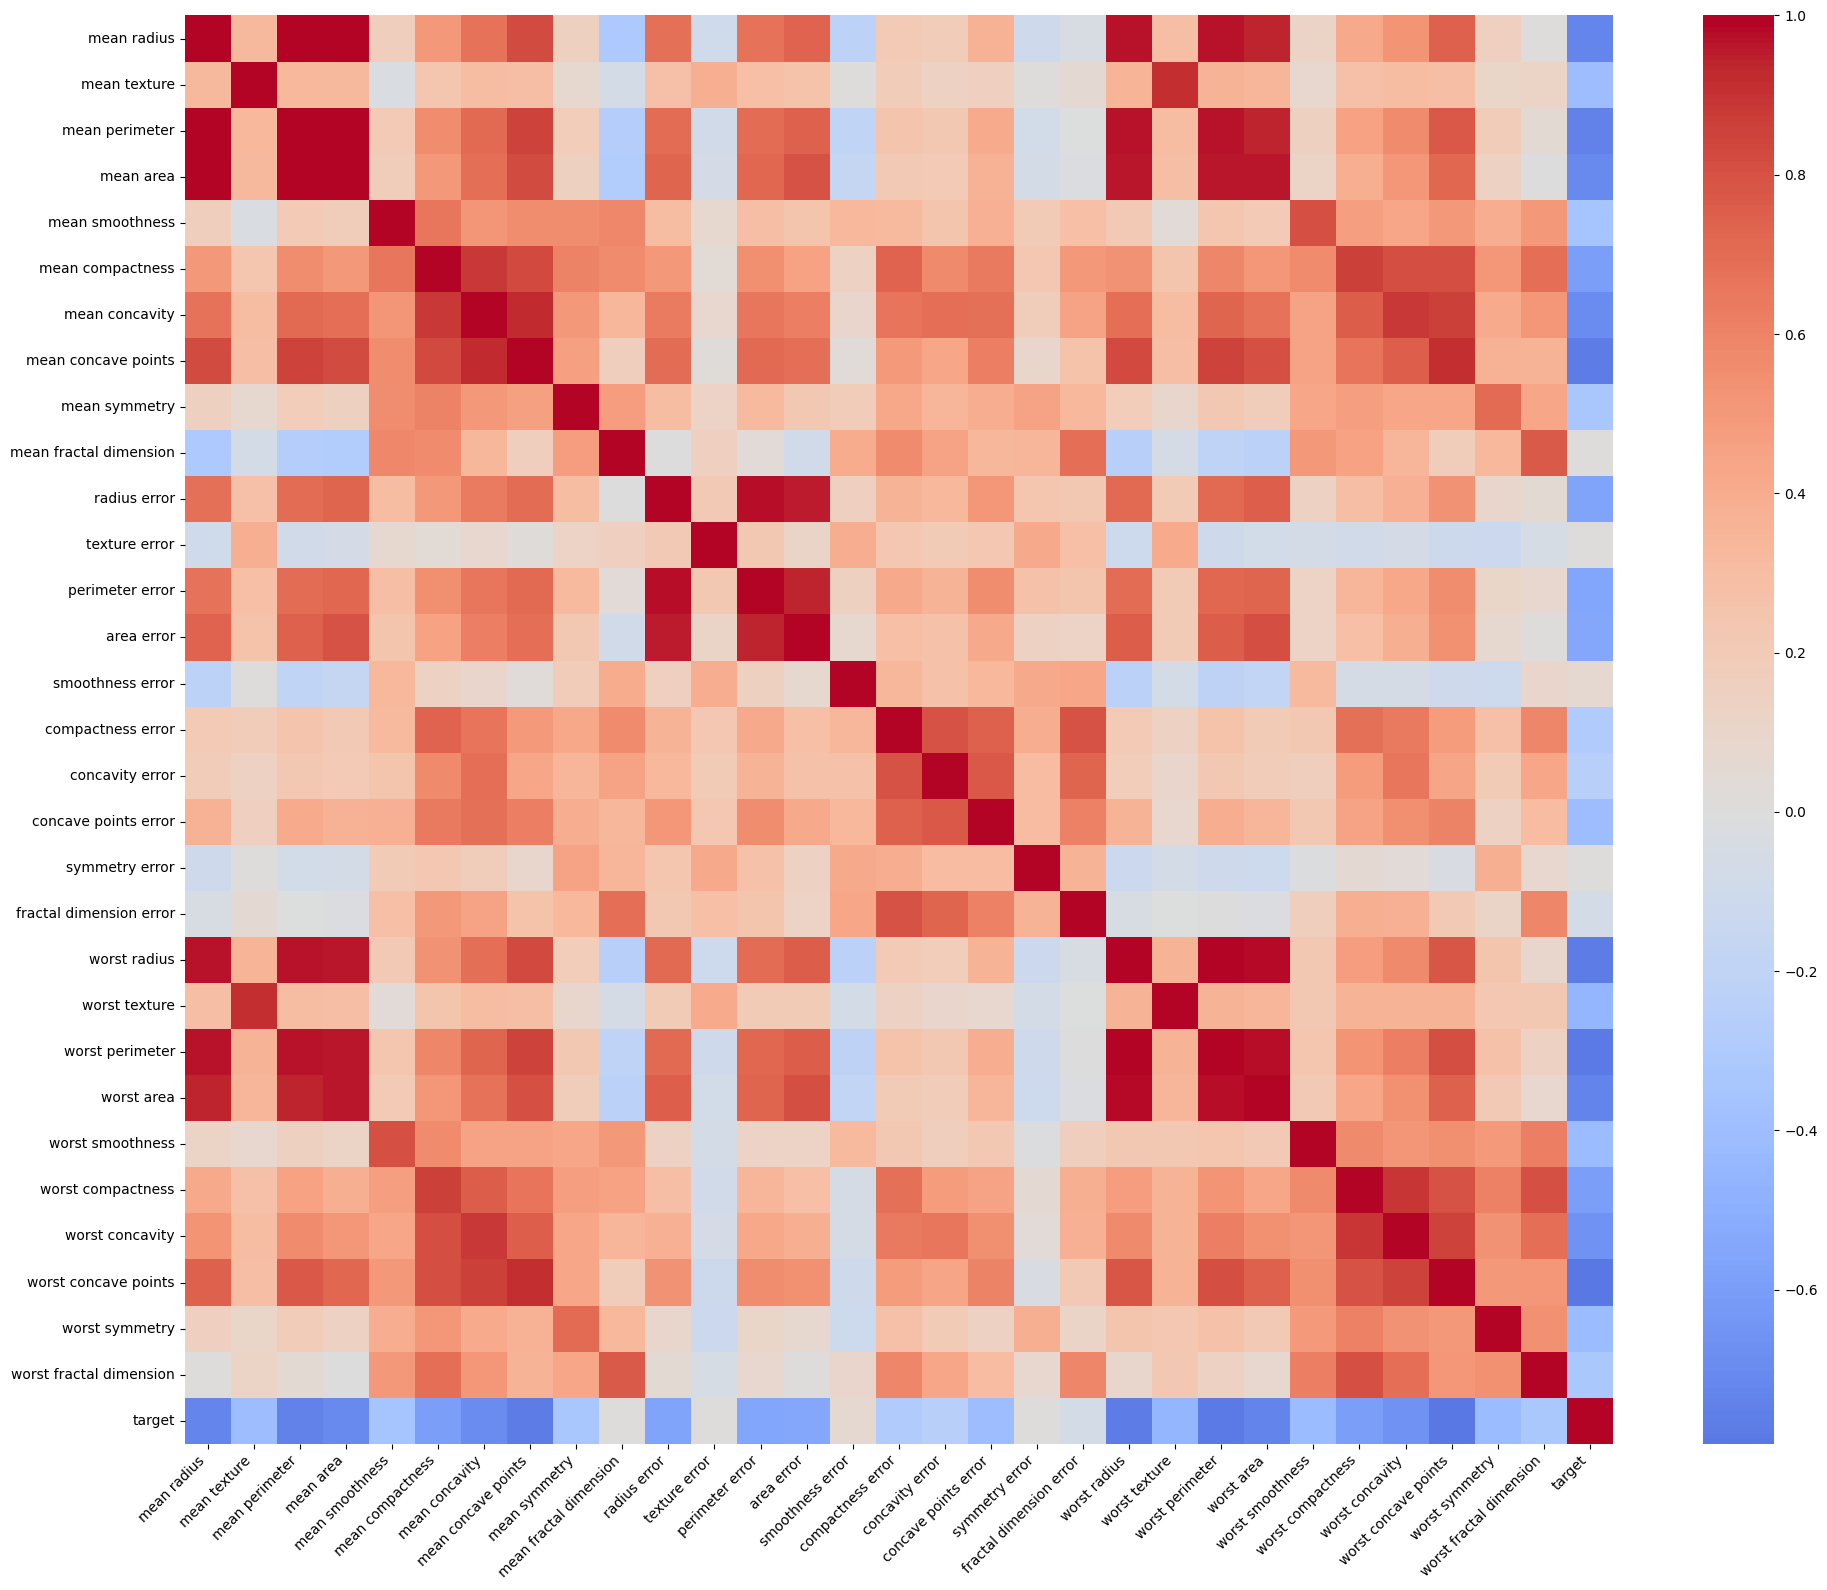

In [118]:
plt.figure(figsize=(20, 16))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [119]:
df.isnull().sum().sum()
df.duplicated().sum()
df['target'].value_counts()

,count
target,
1,357
0,212


In [120]:
X = df.drop('target', axis=1)
y = df['target']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

BASELINE MODEL

In [121]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9122807017543859
Precision: 0.9558823529411765
Recall: 0.9027777777777778
F1: 0.9285714285714286


TUNING BASELINE MODEL

In [122]:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

dt = DecisionTreeClassifier(random_state=42)

param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(range(2, 31)),
   'min_samples_split': np.arange(2, 12),
'min_samples_leaf': np.arange(1, 12),
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None] + list(range(5, 51)),
    'min_impurity_decrease': [0.0, 0.0001, 0.001, 0.01, 0.05],
    'class_weight': [None, 'balanced']
}
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)
best_dt = random_search.best_estimator_
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'splitter': 'random', 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(4), 'min_impurity_decrease': 0.01, 'max_leaf_nodes': 39, 'max_features': None, 'max_depth': 25, 'criterion': 'entropy', 'class_weight': 'balanced'}

Best CV F1:
0.958975125568046
Accuracy: 0.8947368421052632
Precision: 0.9545454545454546
Recall: 0.875
F1: 0.9130434782608695


criterion              = log_loss
max_depth              = 26
max_features           = log2
max_leaf_nodes         = 29
min_samples_split      = 8
min_samples_leaf       = 2
min_impurity_decrease  = 0.01
splitter               = best
class_weight           = None





DEFAULT MODEL-

*   Accuracy: 0.9035087719298246
*   Precision: 0.9420289855072463
*   Recall: 0.9027777777777778
*   F1: 0.9219858156028369


**TUNED MODEL**


> Best CV F1:
0.9632925078813976
Accuracy: 0.9736842105263158
Precision: 0.9726027397260274
Recall: 0.9861111111111112
F1: 0.9793103448275862









In [123]:
# Get feature importances
model=best_dt
importances = model.feature_importances_
feature_names = model.feature_names_in_

# Create a sortable dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
importance_df['Feature'].head(8).to_list()

['mean concave points',
 'worst area',
 'worst compactness',
 'worst smoothness',
 'radius error',
 'worst concave points',
 'worst texture',
 'concave points error']

In [124]:
df2=df[importance_df['Feature'].head(8).to_list()]
X_train2, X_test2, y_train, y_test = train_test_split(
    df2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

dt = DecisionTreeClassifier(random_state=42)

param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(range(2, 31)),
   'min_samples_split': np.arange(2, 12),
'min_samples_leaf': np.arange(1, 12),
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None] + list(range(5, 51)),
    'min_impurity_decrease': [0.0, 0.0001, 0.001, 0.01, 0.05],
    'class_weight': [None, 'balanced']
}
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train2, y_train)
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)
best_dt = random_search.best_estimator_
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_dt.predict(X_test2)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'splitter': 'best', 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(6), 'min_impurity_decrease': 0.01, 'max_leaf_nodes': 20, 'max_features': 'sqrt', 'max_depth': 14, 'criterion': 'log_loss', 'class_weight': None}

Best CV F1:
0.9652713035358881
Accuracy: 0.956140350877193
Precision: 0.971830985915493
Recall: 0.9583333333333334
F1: 0.965034965034965


|                | All features |      Top 8 |
| -------------- | -----------: | ---------: |
| CV F1          |   **0.9633** | **0.9653** |
| Test Accuracy  |   **0.9737** |     0.9561 |
| Test Precision |   **0.9726** | **0.9718** |
| Test Recall    |   **0.9861** |     0.9583 |
| Test F1        |   **0.9793** |     0.9650 |


BAGGING CLASSIFICATION

In [136]:
from sklearn.ensemble import BaggingClassifier
clf=BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, max_samples=100, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=-1, random_state=42, verbose=0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
#

Accuracy: 0.9473684210526315
Precision: 0.9583333333333334
Recall: 0.9583333333333334
F1: 0.9583333333333334


In [137]:
clf.fit(X_train2, y_train)
y_pred2 = clf.predict(X_test2)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1:", f1_score(y_test, y_pred2))

Accuracy: 0.9473684210526315
Precision: 0.9583333333333334
Recall: 0.9583333333333334
F1: 0.9583333333333334


In [139]:
clf2=BaggingClassifier(estimator=model, n_estimators=100, max_samples=100, max_features=1.0, bootstrap=True, bootstrap_features=False, oob_score=False, warm_start=False, n_jobs=-1, random_state=42, verbose=0)

clf2.fit(X_train2, y_train)
y_pred2 = clf2.predict(X_test2)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1:", f1_score(y_test, y_pred2))

Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1: 0.9655172413793104


In [140]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    clf2,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print(scores)
print(scores.mean())

[0.92857143 0.96551724 0.98591549 0.97222222 0.96453901]
0.9633530784445812


In [141]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print(scores)
print(scores.mean())

[0.92198582 0.95890411 0.96453901 0.97222222 0.98571429]
0.960673088044117


**TUNING OF BAGGING MODEL**

In [142]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(10, 301),

    'max_samples': uniform(0.5, 0.5),

    'max_features': uniform(0.5, 0.5),

    'bootstrap': [True, False],

    'bootstrap_features': [True, False]
}
random_search_bag = RandomizedSearchCV(
    estimator=bag,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_bag.fit(X_train2, y_train)
print("Best Parameters:")
print(random_search_bag.best_params_)

print("\nBest CV F1:")
print(random_search_bag.best_score_)
print("Best Parameters:")
print(random_search_bag.best_params_)

print("\nBest CV F1:")
print(random_search_bag.best_score_)
best_bag = random_search_bag.best_estimator_
y_pred = best_bag.predict(X_test2)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'bootstrap': True, 'bootstrap_features': True, 'max_features': np.float64(0.6695148955243504), 'max_samples': np.float64(0.6746047873063304), 'n_estimators': 217}

Best CV F1:
0.9722933270207003
Best Parameters:
{'bootstrap': True, 'bootstrap_features': True, 'max_features': np.float64(0.6695148955243504), 'max_samples': np.float64(0.6746047873063304), 'n_estimators': 217}

Best CV F1:
0.9722933270207003
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231


In [143]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

bag = BaggingClassifier(
    estimator=model,
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(10, 301),

    'max_samples': uniform(0.5, 0.5),

    'max_features': uniform(0.5, 0.5),

    'bootstrap': [True, False],

    'bootstrap_features': [True, False]
}
random_search_bag = RandomizedSearchCV(
    estimator=bag,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_bag.fit(X_train2, y_train)
print("Best Parameters:")
print(random_search_bag.best_params_)

print("\nBest CV F1:")
print(random_search_bag.best_score_)
print("Best Parameters:")
print(random_search_bag.best_params_)

print("\nBest CV F1:")
print(random_search_bag.best_score_)
best_bag = random_search_bag.best_estimator_
y_pred = best_bag.predict(X_test2)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters:
{'bootstrap': True, 'bootstrap_features': False, 'max_features': np.float64(0.9526753209780319), 'max_samples': np.float64(0.5978955673946482), 'n_estimators': 21}

Best CV F1:
0.9721696482585773
Best Parameters:
{'bootstrap': True, 'bootstrap_features': False, 'max_features': np.float64(0.9526753209780319), 'max_samples': np.float64(0.5978955673946482), 'n_estimators': 21}

Best CV F1:
0.9721696482585773
Accuracy: 0.9298245614035088
Precision: 0.9705882352941176
Recall: 0.9166666666666666
F1: 0.9428571428571428


| Model                           | Accuracy |  Precision |     Recall |         F1 |
| ------------------------------- | -------: | ---------: | ---------: | ---------: |
| **Baseline DT**                 |   0.9123 |     0.9559 |     0.9028 |     0.9286 |
| **Tuned DT**                    |   0.8947 |     0.9545 |     0.8750 |     0.9130 |
| **Bagging + baseline DT**       |   0.9474 |     0.9583 |     0.9583 | **0.9583** |
| **Bagging + tuned DT**          |   0.9561 |     0.9589 |     0.9722 | **0.9655** |
| **Tuned Bagging + baseline DT** |   0.9561 |     0.9467 | **0.9861** | **0.9660** |
| **Tuned Bagging + tuned DT**    |   0.9298 | **0.9706** |     0.9167 | **0.9429** |
